In [1]:
from pycocotools.coco import COCO
import os
import shutil
import json
import random
import matplotlib.pyplot as plt
import cv2
import numpy as np
from tqdm import tqdm
from collections import defaultdict

from PIL import Image
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, models
from torch import optim
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F

print("Imports finalizados")


Imports finalizados


In [2]:
from torchvision.models import ResNet18_Weights

In [3]:
# Cargar los pesos
state_dict1 = torch.load('modelo_pesos1.pth')

C:\Users\Juanja Malo\AppData\Local\Temp\ipykernel_38272\678103255.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict1 = torch.load('modelo_pesos1.pth')


In [14]:
class MLC(nn.Module):
    def __init__(self, num_classes):
        super(MLC, self).__init__()
        self.resnet = models.resnet18(weights=None)
        self.in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Linear(self.in_features, num_classes)

    def forward(self, x):
        x = self.resnet(x)
        return x


In [ ]:
print(78)
model = MLC(num_classes=78)
model.resnet

In [ ]:
import torch.nn as nn
import torch
from torchvision import models
# Define the model class (make sure this matches the class used during training)
class MultilabelNN(nn.Module):
    def __init__(self, num_classes):
        super(MultilabelNN, self).__init__()
        self.features = models.resnet50(pretrained=True)
        self.features.fc = nn.Linear(self.features.fc.in_features, num_classes)
    
    def forward(self, x):
        x = self.features(x)
        return torch.sigmoid(x)

# Load the model
num_classes = totalLabels  # Make sure this matches the number of classes used during training
model = MultilabelNN(num_classes)
model.load_state_dict(torch.load(model_path))
model = model.cuda() if torch.cuda.is_available() else model
model.eval()
print("Model loaded and set to evaluation mode")

In [7]:
# Load the model
model = MultilabelNN(num_classes)
model.load_state_dict(torch.load(model_path))
model = model.cuda() if torch.cuda.is_available() else model
model.eval()
print("Model loaded and set to evaluation mode")

NameError: name 'num_classes' is not defined

In [ ]:
# Example prediction
def predict(image_path):
    image = Image.open(image_path).convert('RGB')
    image = transform(image).unsqueeze(0)  # Add batch dimension
    image = image.cuda() if torch.cuda.is_available() else image
    with torch.no_grad():
        output = model(image)
    return output

# Predict on a new image
image_path = "path_to_your_image.jpg"
prediction = predict(image_path)
print(f"Prediction: {prediction}")

In [15]:
import torch
from torchvision import models, transforms
from PIL import Image

# Cargar el modelo
model = models.resnet18(weights=None)

model = MLC(num_classes=78)
model.resnet



ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [16]:

# Cargar el state_dict y ajustar las claves
state_dict = torch.load("modelo_pesos1.pth")
new_state_dict = {k.replace('resnet.', ''): v for k, v in state_dict.items()}
model.load_state_dict(new_state_dict)
model.eval()  # Poner el modelo en modo de evaluación

C:\Users\Juanja Malo\AppData\Local\Temp\ipykernel_38272\3494109352.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("modelo_pesos1.pth")


RuntimeError: Error(s) in loading state_dict for MLC:
	Missing key(s) in state_dict: "resnet.conv1.weight", "resnet.bn1.weight", "resnet.bn1.bias", "resnet.bn1.running_mean", "resnet.bn1.running_var", "resnet.layer1.0.conv1.weight", "resnet.layer1.0.bn1.weight", "resnet.layer1.0.bn1.bias", "resnet.layer1.0.bn1.running_mean", "resnet.layer1.0.bn1.running_var", "resnet.layer1.0.conv2.weight", "resnet.layer1.0.bn2.weight", "resnet.layer1.0.bn2.bias", "resnet.layer1.0.bn2.running_mean", "resnet.layer1.0.bn2.running_var", "resnet.layer1.1.conv1.weight", "resnet.layer1.1.bn1.weight", "resnet.layer1.1.bn1.bias", "resnet.layer1.1.bn1.running_mean", "resnet.layer1.1.bn1.running_var", "resnet.layer1.1.conv2.weight", "resnet.layer1.1.bn2.weight", "resnet.layer1.1.bn2.bias", "resnet.layer1.1.bn2.running_mean", "resnet.layer1.1.bn2.running_var", "resnet.layer2.0.conv1.weight", "resnet.layer2.0.bn1.weight", "resnet.layer2.0.bn1.bias", "resnet.layer2.0.bn1.running_mean", "resnet.layer2.0.bn1.running_

In [ ]:

# Definir las transformaciones para la imagen
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Cargar y preprocesar la imagen
img_path = "ruta_a_tu_imagen.jpg"
img = Image.open(img_path)
img_tensor = preprocess(img)
img_tensor = img_tensor.unsqueeze(0)  # Añadir una dimensión para el batch

# Hacer la predicción
with torch.no_grad():
    output = model(img_tensor)
    _, predicted = torch.max(output, 1)

print(f"Predicción: {predicted.item()}")

In [44]:
from pycocotools.coco import COCO
import os
import shutil
import json
import random
import matplotlib.pyplot as plt
import cv2
import numpy as np
from tqdm import tqdm
from collections import defaultdict

from PIL import Image
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, models
from torch import optim
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import ResNet18_Weights

In [45]:
output_dir = r"F:\Train_IA\train2017\BalancedDataset"
annotations_output_path = os.path.join(output_dir, 'annotations/custom_annotations.json')

In [46]:
# Cargar el nuevo dataset
custom_coco = COCO(annotations_output_path)
totalLabels=0

# Verificar imágenes por categoría
for cat in custom_coco.loadCats(custom_coco.getCatIds()):
    totalLabels+=1
    img_ids = custom_coco.getImgIds(catIds=[cat['id']])
    print(f"Categoría: {cat['name']}, Imágenes: {len(img_ids)}")
    
print(f"\nTotal de categorías: {totalLabels}")

# Verificar que todas las anotaciones tienen una imagen válida
# for ann in custom_coco.loadAnns(custom_coco.getAnnIds()):
#     assert ann['image_id'] in custom_coco.getImgIds(), f"Anotación con imagen inexistente: {ann}"

print("Validación completada: Todas las imágenes y anotaciones son consistentes.")

loading annotations into memory...
Done (t=8.20s)
creating index...
index created!
Categoría: person, Imágenes: 24533
Categoría: bicycle, Imágenes: 1575
Categoría: car, Imágenes: 5073
Categoría: motorcycle, Imágenes: 1294
Categoría: airplane, Imágenes: 849
Categoría: bus, Imágenes: 1519
Categoría: train, Imágenes: 1056
Categoría: truck, Imágenes: 2422
Categoría: boat, Imágenes: 1075
Categoría: traffic light, Imágenes: 1657
Categoría: fire hydrant, Imágenes: 879
Categoría: stop sign, Imágenes: 888
Categoría: parking meter, Imágenes: 700
Categoría: bench, Imágenes: 2182
Categoría: bird, Imágenes: 1143
Categoría: cat, Imágenes: 1580
Categoría: dog, Imágenes: 1768
Categoría: horse, Imágenes: 984
Categoría: sheep, Imágenes: 783
Categoría: cow, Imágenes: 860
Categoría: elephant, Imágenes: 806
Categoría: bear, Imágenes: 709
Categoría: zebra, Imágenes: 775
Categoría: giraffe, Imágenes: 801
Categoría: backpack, Imágenes: 2552
Categoría: umbrella, Imágenes: 1572
Categoría: handbag, Imágenes: 312

In [47]:
# Ruta del archivo de anotaciones y las imágenes del dataset personalizado
annotations_path = r"F:\Train_IA\train2017\BalancedDataset\annotations\custom_annotations.json"
images_dir = r"F:\Train_IA\train2017\BalancedDataset\normalized_images"

# Cargar las anotaciones del dataset personalizado
coco = COCO(annotations_path)


loading annotations into memory...
Done (t=8.43s)
creating index...
index created!


In [48]:
model = models.resnet18(weights=None)


In [49]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [50]:
class MLC(nn.Module):
    def __init__(self, num_classes):
        super(MLC, self).__init__()
        self.resnet = models.resnet18(weights=None)
        self.in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Linear(self.in_features, num_classes)

    def forward(self, x):
        x = self.resnet(x)
        return x


In [51]:
# Definir los dispositivos (GPU si está disponible)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo actual:", device)
# Cargar el archivo de anotaciones final
annotations_path = r"F:\Train_IA\train2017\BalancedDataset\annotations\custom_annotations.json"
coco = COCO(annotations_path)

# Obtener las categorías y asignarlas a un índice
categories = coco.loadCats(coco.getCatIds())
category_names = {cat['id']: cat['name'] for cat in categories}

# Cargar las imágenes y sus anotaciones
image_ids = coco.getImgIds()
images_info = coco.loadImgs(image_ids)

# Definir las transformaciones para el preprocesamiento de las imágenes
transform = transforms.Compose([
    transforms.ToTensor(),  # Convertir la imagen a un tensor
    transforms.Resize((224, 224)),  # Redimensionar las imágenes a 224x224
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalizar
])

# Función para cargar las anotaciones
def load_annotations(img_id):
    ann_ids = coco.getAnnIds(imgIds=[img_id])
    annotations = coco.loadAnns(ann_ids)
    labels = [ann['category_id'] for ann in annotations]
    
    # Filtrar las etiquetas para que estén dentro del rango de las categorías disponibles
    valid_labels = [label - 1 for label in labels if 1 <= label <= len(categories)]
    
    return valid_labels

# Crear un Dataset para PyTorch
class CocoDataset(torch.utils.data.Dataset):
    def __init__(self, coco, images_info, categories, transform=None):
        self.coco = coco
        self.images_info = images_info
        self.categories = categories
        self.transform = transform
        
    def __len__(self):
        return len(self.images_info)
    
    def __getitem__(self, idx):
        img_info = self.images_info[idx]
        img_id = img_info['id']
        img_path = os.path.join('F:/Train_IA/train2017/train2017', img_info['file_name'])
        
        image = datasets.folder.default_loader(img_path)  # Cargar la imagen
        if self.transform:
            image = self.transform(image)  # Aplicar las transformaciones
        
        labels = load_annotations(img_id)  # Obtener las etiquetas para la imagen
        labels_tensor = torch.zeros(len(self.categories))  # Crear un tensor para las etiquetas
        
        # Marcar las posiciones correspondientes en el tensor de etiquetas
        for label in labels:
            labels_tensor[label] = 1  # Marcar la categoría correspondiente
        
        return image, labels_tensor

# Crear el DataLoader
dataset = CocoDataset(coco, images_info, categories, transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

Dispositivo actual: cuda
loading annotations into memory...
Done (t=9.44s)
creating index...
index created!


In [52]:
print(len(categories))
model = MLC(num_classes=len(categories))
model.resnet
model = model.to(device)

78


In [53]:
state_dict = torch.load("modelo_pesos1.pth")
new_state_dict = {k.replace('resnet.', ''): v for k, v in state_dict.items()}
model.resnet.load_state_dict(new_state_dict, strict=False)
model.eval()  # Poner el modelo en modo de evaluación


C:\Users\Juanja Malo\AppData\Local\Temp\ipykernel_38272\3580790912.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("modelo_pesos1.pth")


MLC(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_

In [54]:
# Crear un mapeo de índice a ID de categoría
id_to_index = {cat['id']: i for i, cat in enumerate(categories)}  # De COCO ID a índice
index_to_id = {v: k for k, v in id_to_index.items()}  # De índice a COCO ID
category_names = {cat['id']: cat['name'] for cat in categories}  # De COCO ID a nombre


In [55]:
import matplotlib.pyplot as plt
from PIL import Image

def predict_and_show(image_path, model, coco):
    model.eval()  # Poner el modelo en modo evaluación
    image = datasets.folder.default_loader(image_path)  # Cargar la imagen
    image_transformed = transform(image).unsqueeze(0).to(device)  # Aplicar transformaciones
    
    with torch.no_grad():
        outputs = model(image_transformed)  # Inferencia
        
    # Aplicar sigmoid para obtener probabilidades
    probs = torch.sigmoid(outputs).cpu().numpy()
    
    # Obtener los índices predichos (según el mapeo del modelo)
    predicted_indices = [i for i, p in enumerate(probs[0]) if p > 0.5]
    
    # Convertir índices a IDs de categoría (usando el mapeo index_to_id)
    predicted_ids = [index_to_id[i] for i in predicted_indices]
    
    # Obtener los nombres de las categorías
    labels = [category_names[cat_id] for cat_id in predicted_ids]
    
    # Mostrar la imagen con las etiquetas predichas
    plt.figure(figsize=(8, 8))
    plt.imshow(image)  # Mostrar la imagen
    plt.axis('off')  # Quitar ejes
    plt.title(f"Predicciones: {', '.join(labels)}", fontsize=12)  # Agregar las etiquetas como título
    plt.show()
    
    return labels

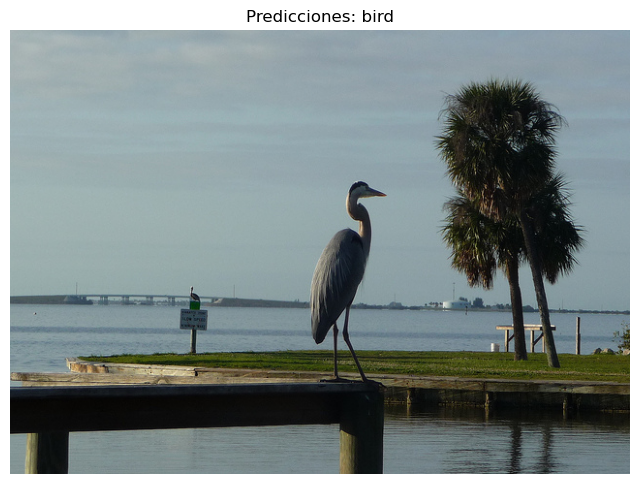

Etiquetas predichas:
['bird']


In [56]:
image_path = "F:/Train_IA/train2017/train2017/000000250680.jpg"  # Cambia a la ruta de tu imagen
predicted_labels = predict_and_show(image_path, model, coco)
print("Etiquetas predichas:")
print(predicted_labels)

In [23]:
import torch
from torchvision import models, transforms
from PIL import Image

# Definir tu clase MLC
class MLC(torch.nn.Module):
    def __init__(self, num_classes=78):
        super(MLC, self).__init__()
        self.resnet = models.resnet18(weights=None)
        self.resnet.fc = torch.nn.Linear(self.resnet.fc.in_features, num_classes)

    def forward(self, x):
        return self.resnet(x)

# Cargar el modelo
model = MLC(num_classes=78)

# Cargar el state_dict y ajustar las claves
state_dict = torch.load("modelo_pesos1.pth")
new_state_dict = {k.replace('resnet.', ''): v for k, v in state_dict.items()}
model.resnet.load_state_dict(new_state_dict, strict=False)
model.eval()  # Poner el modelo en modo de evaluación

# Definir las transformaciones para la imagen
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Cargar y preprocesar la imagen
img_path = "F:/Train_IA/train2017/train2017/000000250680.jpg"
img = Image.open(img_path)
img_tensor = preprocess(img)
img_tensor = img_tensor.unsqueeze(0)  # Añadir una dimensión para el batch

# Hacer la predicción
with torch.no_grad():
    output = model(img_tensor)
    _, predicted = torch.max(output, 1)

print(f"Predicción: {predicted.item()}")

Predicción: 14


C:\Users\Juanja Malo\AppData\Local\Temp\ipykernel_38272\3243209351.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("modelo_pesos1.pth")
